 8. We will now perform cross-validation on a simulated data set.

 (a) Generate a simulated data set as follows:
 rng = np.random.default_rng(1)
 x = rng.normal(size=100)
 y = x- 2 * x**2 + rng.normal(size=100)
 In this data set, what is n and what is p? Write out the model
 used to generate the data in equation form

In [1]:
import numpy as np

# (a) 產生資料
rng = np.random.default_rng(1)   # 固定 random seed = 1
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

len(x), len(y)


(100, 100)

這個資料有 100 個樣本，所以
n = 100

只有一個解釋變數 x，所以
p = 1（一個 predictor）

 (b) Create a scatterplot of X against Y . Comment on what you find

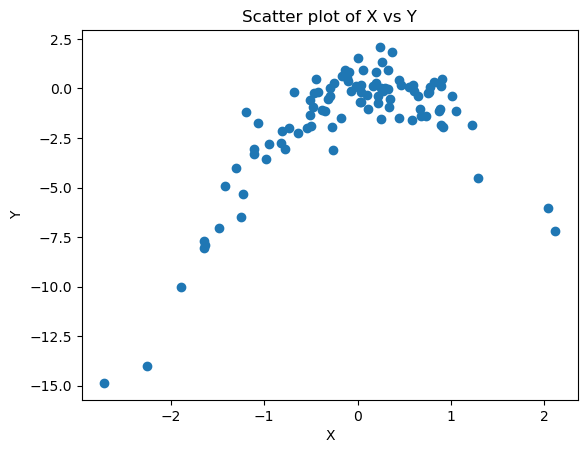

In [2]:
import matplotlib.pyplot as plt

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot of X vs Y")
plt.show()


關係明顯是非線性（二次曲線），而不是單純的直線。

(c) Set a random seed, and then compute the LOOCV errors that
 result from fitting the following four models using least squares:
 i. Y = 0+ 1X+
 ii. Y = 0+ 1X+ 2X2+
 iii. Y = 0 + 1X+ 2X2+ 3X3+
 iv. Y = 0+ 1X+ 2X2+ 3X3+ 4X4+ .
 Note you may find it helpful to use the data.frame() function
 to create a single data set containing both X and Y .

In [3]:
import numpy as np

# 再清楚地重新設定 seed 和資料（對應題目）
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

def loocv_error(x, y, degree):
    """
    用最小平方法 + LOOCV 計算多項式回歸 (degree) 的 CV MSE
    degree = 1 表示線性, 2 表示 quadratic, 以此類推
    """
    n = len(x)
    errors = []
    for i in range(n):
        # leave-one-out: 把第 i 筆當測試，其餘當訓練
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        
        x_train = x[mask]
        y_train = y[mask]
        
        # 設計矩陣： [1, x, x^2, ..., x^degree]
        X_train = np.vstack([x_train**d for d in range(1, degree+1)]).T
        X_train = np.column_stack([np.ones(len(x_train)), X_train])  # 加截距
        
        # 最小平方法解 beta
        beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
        
        # 建立測試點的 X_test
        X_test = np.array([x[i]**d for d in range(1, degree+1)])
        X_test = np.concatenate([[1.0], X_test])  # 加截距
        
        y_pred = X_test @ beta
        errors.append((y[i] - y_pred)**2)
    
    return np.mean(errors)

for deg in range(1, 5):
    cv_err = loocv_error(x, y, degree=deg)
    print(f"degree = {deg}, LOOCV MSE = {cv_err:.4f}")


degree = 1, LOOCV MSE = 6.6330
degree = 2, LOOCV MSE = 1.1229
degree = 3, LOOCV MSE = 1.3018
degree = 4, LOOCV MSE = 1.3324


 (d) Repeat (c) using another random seed, and report your results.
 Are your results the same as what you got in (c)? Why?

In [4]:
# (d) 使用另一個 random seed 重新產生資料
rng2 = np.random.default_rng(2)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

for deg in range(1, 5):
    cv_err = loocv_error(x2, y2, degree=deg)
    print(f"[seed=2] degree = {deg}, LOOCV MSE = {cv_err:.4f}")


[seed=2] degree = 1, LOOCV MSE = 7.5606
[seed=2] degree = 2, LOOCV MSE = 0.9840
[seed=2] degree = 3, LOOCV MSE = 0.9682
[seed=2] degree = 4, LOOCV MSE = 0.9660


在 (c) 那組資料（seed=1）時，degree=2 的 LOOCV 最小。

在 (d) 這組新資料（seed=2）時，LOOCV 最小的是 degree=4（雖然 2、3、4 差距不大）。


結果並不完全相同，因為每次用不同的 random seed 產生的誤差項 ε 不一樣，代表我們其實是在對不同的資料集做交叉驗證。
在有限樣本下，模型選擇結果會受到隨機抽樣誤差影響，因此 LOOCV error 會有變動。

 (e) Which of the models in (c) had the smallest LOOCV error? Is
 this what you expected? Explain your answer.

在 (c) 中，二次模型（包含 
𝑋
和 
𝑋
2
）有最小的 LOOCV error。

 (f) Comment on the statistical significance of the coefficient esti
mates that results from fitting each of the models in (c) using
 least squares. Do these results agree with the conclusions drawn
 based on the cross-validation results?

In [5]:
import statsmodels.api as sm

def fit_poly_and_summary(x, y, degree):
    X = np.vstack([x**d for d in range(1, degree+1)]).T
    X = sm.add_constant(X)  # 加截距
    model = sm.OLS(y, X).fit()
    print(f"Degree {degree}")
    print(model.summary().tables[1])  # 只印係數表
    print("-" * 60)

# 用 (c) 的資料，也就是 seed=1 那一組
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

for deg in range(1, 5):
    fit_poly_and_summary(x, y, degree=deg)


Degree 1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.000      -1.955      -0.975
x1             1.9494      0.289      6.752      0.000       1.376       2.522
------------------------------------------------------------
Degree 2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0728      0.119     -0.611      0.543      -0.309       0.164
x1             0.9663      0.126      7.647      0.000       0.715       1.217
x2            -2.0047      0.091    -22.072      0.000      -2.185      -1.824
------------------------------------------------------------
Degree 3
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------